# Study 1: Annotation Consistency Analysis

| Section | Focus | Metrics |
|---|---|---|
| A | Intra-annotator reliability | Krippendorff α, Spearman ρ, MAD, mean signed drift (MSD) |
| B | Inter-annotator agreement | Krippendorff α, Spearman ρ, MAD |
| C | Distributional analysis | Total score distributions, score distributions, exact agreement, spread map |

**Models:** GPT-4o (frontier), Claude Sonnet (mid-tier, Constitutional AI), Llama 3.1-8B (small open-weight)

**Note on mean_drift_H1-H2:** This column is the Mean Signed Drift (MSD) as defined in the dissertation methodology (Section 3.4.4).
MSD = mean(H1 score − H2 score). Positive = H1 scored higher; negative = H2 scored higher (recalibration upward in Phase 2).


## 0. Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import krippendorff
from scipy.stats import spearmanr
from itertools import combinations

warnings.filterwarnings("ignore")


In [2]:
# File paths
INPUT_H1   = "annotations/human_phase1.csv"
INPUT_H2   = "annotations/human_phase2.csv"
INPUT_LLM  = "annotations/llm_annotations.csv"
TWEETS_300 = "datasets/sampled_tweets_300.csv"   # used for engagement distribution check
OUTPUT_DIR = "study1"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

SCORE_COLS   = [f"V{i}" for i in range(1, 9)]
VALID_SCORES = [1, 2, 3]

# Model display names (must match llm_name_version strings in CSV)
LLM_DISPLAY = {
    "gpt-4o-2024-08-06":                            "GPT-4o",
    "claude-sonnet-4-6":                            "Claude Sonnet",
    "meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo": "Llama 3.1-8B",
}

os.makedirs(FIGURE_DIR, exist_ok=True)
print("Configuration loaded.")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Figure dir : {FIGURE_DIR}")


Configuration loaded.
  Output dir : study1
  Figure dir : study1/figures


In [3]:
print(os.getcwd())

/Users/mariameshi/Documents/year_5/Thesis/Code/LLM_annotations


## 1. Load & Validate Data

In [4]:
# Load CSV; report and drop rows with out-of-range scores."
def load_and_validate(path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    missing = [c for c in ["tweet_id"] + SCORE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"[{label}] Missing columns: {missing}")
    dropped_ids = set()
    for col in SCORE_COLS:
        invalid = df[~df[col].isin(VALID_SCORES)]
        if len(invalid):
            ids = invalid["tweet_id"].tolist()
            dropped_ids.update(ids)
            print(f"  WARNING [{label}] {len(invalid)} invalid scores in {col}:")
            print(f"    tweet_id(s) : {ids}")
            print(f"    raw value(s): {invalid[col].tolist()}")
            df = df[df[col].isin(VALID_SCORES)]
    if dropped_ids:
        print(f"  DROPPED {len(dropped_ids)} row(s) total: {sorted(dropped_ids)}")
    df["tweet_id"] = df["tweet_id"].astype(str)
    print(f"  Loaded [{label}]: {len(df)} rows")
    return df


h1  = load_and_validate(INPUT_H1, "Human Phase 1")
h2  = load_and_validate(INPUT_H2, "Human Phase 2")
llm = pd.read_csv(INPUT_LLM)
llm["tweet_id"] = llm["tweet_id"].astype(str)
print(f"  Loaded [LLM annotations]: {len(llm)} rows "
      f"across {llm['llm_name_version'].nunique()} models")
print(f"  Models present: {llm['llm_name_version'].unique().tolist()}")


  WARNING [Human Phase 1] 7 invalid scores in V1:
    tweet_id(s) : [66, 211, 405, 406, 436, 437, 445]
    raw value(s): [nan, nan, nan, nan, nan, nan, nan]
  WARNING [Human Phase 1] 1 invalid scores in V2:
    tweet_id(s) : [434]
    raw value(s): [nan]
  WARNING [Human Phase 1] 1 invalid scores in V4:
    tweet_id(s) : [70]
    raw value(s): [11.0]
  WARNING [Human Phase 1] 1 invalid scores in V7:
    tweet_id(s) : [42]
    raw value(s): [nan]
  DROPPED 10 row(s) total: [42, 66, 70, 211, 405, 406, 434, 436, 437, 445]
  Loaded [Human Phase 1]: 291 rows
  Loaded [Human Phase 2]: 50 rows
  Loaded [LLM annotations]: 652 rows across 3 models
  Models present: ['gpt-4o-2024-08-06', 'meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo', 'claude-sonnet-4-6']


## 2. Build the 50-Tweet Overlap Core

All reliability metrics are computed on this overlap.
The overlap is defined by tweets present in Phase 2 (the re-annotation set).


In [5]:
overlap_ids = set(h2["tweet_id"])
h1_overlap  = h1[h1["tweet_id"].isin(overlap_ids)].copy()

print(f"Overlap size: {len(overlap_ids)} tweets")

missing_in_h1  = overlap_ids - set(h1["tweet_id"])
missing_in_llm = overlap_ids - set(llm["tweet_id"])
if missing_in_h1:
    print(f"  WARNING: {len(missing_in_h1)} Phase 2 tweets not found in Phase 1")
if missing_in_llm:
    print(f"  WARNING: {len(missing_in_llm)} Phase 2 tweets not found in LLM file")


Overlap size: 50 tweets


## 3. Build Aligned Annotation Matrices

In [7]:
def get_llm_scores(llm_df, model_version, ids):
    subset = llm_df[
        (llm_df["llm_name_version"] == model_version) &
        (llm_df["tweet_id"].isin(ids))
    ][["tweet_id"] + SCORE_COLS].copy()
    return subset.set_index("tweet_id")


h1_mat = h1_overlap.set_index("tweet_id")[SCORE_COLS]
h2_mat = h2.set_index("tweet_id")[SCORE_COLS]

llm_mats = {}
for model in llm["llm_name_version"].unique():
    display_name = LLM_DISPLAY.get(model, model)
    mat = get_llm_scores(llm, model, overlap_ids)
    if len(mat) > 0:
        llm_mats[display_name] = mat
        print(f"  LLM matrix [{display_name}]: {len(mat)} tweets")

# Remove legacy Claude Haiku rows if present (replaced by Claude Sonnet)
HAIKU_STRING = "claude-haiku-4-5-20251001"
if HAIKU_STRING in llm_mats:
    del llm_mats[HAIKU_STRING]
    print(f"  Removed legacy '{HAIKU_STRING}' from llm_mats")

# Align to common tweet index across all annotators
common_ids = set(h1_mat.index) & set(h2_mat.index)
for mat in llm_mats.values():
    common_ids &= set(mat.index)
common_ids = sorted(common_ids)
print(f"\n  Fully aligned core: {len(common_ids)} tweets across all annotators")

h1_mat = h1_mat.loc[common_ids]
h2_mat = h2_mat.loc[common_ids]
for k in llm_mats:
    llm_mats[k] = llm_mats[k].loc[common_ids]

# Annotator registry and display order
annotators = {"Human P1": h1_mat, "Human P2": h2_mat, **llm_mats}
print(f"  Annotators registered: {list(annotators.keys())}")

PALETTE = {
    "Human P1":      "#12436D",
    "Human P2":      "#28A197",
    "GPT-4o":        "#801650",
    "Claude Sonnet": "#F46A25",
    "Llama 3.1-8B":  "#A285D1",
}
ANNOTATOR_ORDER = [a for a in PALETTE if a in annotators]
print(f"  ANNOTATOR_ORDER: {ANNOTATOR_ORDER}")


  LLM matrix [GPT-4o]: 50 tweets
  LLM matrix [Llama 3.1-8B]: 50 tweets
  LLM matrix [Claude Sonnet]: 50 tweets

  Fully aligned core: 50 tweets across all annotators
  Annotators registered: ['Human P1', 'Human P2', 'GPT-4o', 'Llama 3.1-8B', 'Claude Sonnet']
  ANNOTATOR_ORDER: ['Human P1', 'Human P2', 'GPT-4o', 'Claude Sonnet', 'Llama 3.1-8B']


## 4. Helper Functions

In [9]:
# Krippendorff's alpha (ordinal) across a list of score DataFrames.
# Package: krippendorff (pip install krippendorff)
def krippendorff_alpha(matrices, variable):
    try:
        data = np.array([m[variable].values for m in matrices], dtype=float)
        return krippendorff.alpha(
            reliability_data=data, level_of_measurement="ordinal"
        )
    except Exception:
        return np.nan


# Spearman rho and p-value between two score vectors.
# Computed via scipy.stats.spearmanr
def spearman_rho(a, b):
    try:
        return spearmanr(a, b)
    except Exception:
        return (np.nan, np.nan)


# Mean Absolute Deviation (MAD): average absolute score difference.
def mean_abs_deviation(a, b):
    return float(np.mean(np.abs(a - b)))


print("Helper functions defined: krippendorff_alpha, spearman_rho, mean_abs_deviation")


Helper functions defined: krippendorff_alpha, spearman_rho, mean_abs_deviation


## 5. Shared Design Constants & Plot Helpers

In [10]:
# Variables with floor effect (>90% of scores at minimum value of 1).
# These are excluded from substantive reliability interpretation.
FLOOR_EFFECT_VARS = {"V2", "V3", "V4"}
FLOOR_EFFECT_NOTES = {
    "V2": "92% score 1",
    "V3": "98% score 1",
    "V4": "100% score 1",
}

THRESHOLD_LOW  = 0.67   # tentative agreement threshold
THRESHOLD_HIGH = 0.80   # reliable agreement threshold

VARIABLE_LABELS = {
    "V1": "V1\nPartisan\nAnimosity",
    "V2": "V2\nUndemocratic\nPractices",
    "V3": "V3\nPartisan\nViolence",
    "V4": "V4\nUndemocratic\nCandidates",
    "V5": "V5\nOpp. to\nBipartisanship",
    "V6": "V6\nSocial\nDistrust",
    "V7": "V7\nSocial\nDistance",
    "V8": "V8\nBiased Fact\nEvaluation",
}

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "Helvetica"],
    "font.size":       8,
    "axes.titlesize":  9.5,
    "axes.labelsize":  8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
})


def apply_zone_bands(ax, y_min=-0.25, y_max=1.08):
    for y in np.arange(round(y_min, 1), y_max, 0.1):
        ax.axhline(y, color="#E2E8F0", linewidth=0.6, zorder=0)
    ax.axhspan(THRESHOLD_HIGH, y_max,         color="#DCFCE7", alpha=0.4, zorder=0)
    ax.axhspan(THRESHOLD_LOW, THRESHOLD_HIGH, color="#FEF9C3", alpha=0.4, zorder=0)
    ax.axhspan(y_min, THRESHOLD_LOW,          color="#FEE2E2", alpha=0.2, zorder=0)
    ax.axhline(0, color="#94A3B8", linewidth=0.9, linestyle="--", zorder=1)


def style_axes(ax):
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.spines["left"].set_color("#CBD5E1")
    ax.tick_params(axis="both", labelsize=9)


def save_fig(fig, stem):
    path = os.path.join(FIGURE_DIR, stem + ".png")
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {path}")

print("Design constants and plot helpers defined.")


Design constants and plot helpers defined.


---
## Section A: Intra-Annotator Reliability (H1 vs H2)

Measures how consistently the human annotator applies the AAPA codebook across the
one-week interval between Phase 1 and Phase 2 (n = 50 tweets).

**Metrics computed:**
- Krippendorff's alpha (ordinal)
- Spearman's rho  
- Mean absolute deviation (MAD) (magnitude of score drift)
- Mean score drift (MSD) (mean_drift_H1-H2 )
  - Positive values = H1 scored higher
  - Negative values = H2 scored higher.
- Exact agreement rate (pct_exact_agree )


In [12]:
intra_records = []
for v in SCORE_COLS:
    a = h1_mat[v].values
    b = h2_mat[v].values

    alpha     = krippendorff_alpha([h1_mat, h2_mat], v)
    rho, pval = spearman_rho(a, b)
    mad       = mean_abs_deviation(a, b)
    # Mean Signed Drift (MSD): positive = H1 higher, negative = H2 higher
    drift     = float(np.mean(a.astype(float) - b.astype(float)))
    pct_agree = float(np.mean(a == b))

    intra_records.append({
        "variable":           v,
        "krippendorff_alpha": round(alpha, 3) if not np.isnan(alpha) else np.nan,
        "spearman_rho":       round(rho, 3),
        "spearman_p":         round(pval, 4),
        "MAD":                round(mad, 3),
        "mean_drift_H1-H2":   round(drift, 3),   # MSD: see note above
        "pct_exact_agree":    round(pct_agree, 3),
    })

intra_df = pd.DataFrame(intra_records).set_index("variable")
intra_df.to_csv(os.path.join(OUTPUT_DIR, "sectionA_intra_annotator.csv"))
print("Intra-annotator metrics computed.")


Intra-annotator metrics computed.


### Table A1: Intra-Annotator Summary (H1 vs H2)

In [13]:
display(intra_df.round(3))


,krippendorff_alpha,spearman_rho,spearman_p,MAD,mean_drift_H1-H2,pct_exact_agree
variable,,,,,,
V1,0.695,0.700,0.000,0.32,0.08,0.70
V2,-0.042,-0.042,0.772,0.10,0.06,0.90
V3,-0.010,-0.020,0.888,0.04,0.00,0.96
V4,NaN,NaN,NaN,0.00,0.00,1.00
V5,0.355,0.351,0.012,0.40,0.00,0.62
V6,0.229,0.224,0.118,0.38,-0.02,0.64
V7,-0.026,0.033,0.822,0.46,-0.26,0.58
V8,0.321,0.479,0.000,0.44,-0.40,0.60


### Table A2: Spearman ρ (H1 vs H2)

In [14]:
display(intra_df[["spearman_rho", "spearman_p"]].round(3))


,spearman_rho,spearman_p
variable,,
V1,0.700,0.000
V2,-0.042,0.772
V3,-0.020,0.888
V4,NaN,NaN
V5,0.351,0.012
V6,0.224,0.118
V7,0.033,0.822
V8,0.479,0.000


### Table A3: Krippendorff's α (H1 vs H2)

In [15]:
display(intra_df[["krippendorff_alpha"]].round(3))


,krippendorff_alpha
variable,
V1,0.695
V2,-0.042
V3,-0.010
V4,NaN
V5,0.355
V6,0.229
V7,-0.026
V8,0.321


### Figure A2: Intra-Annotator Spearman ρ Bar Chart

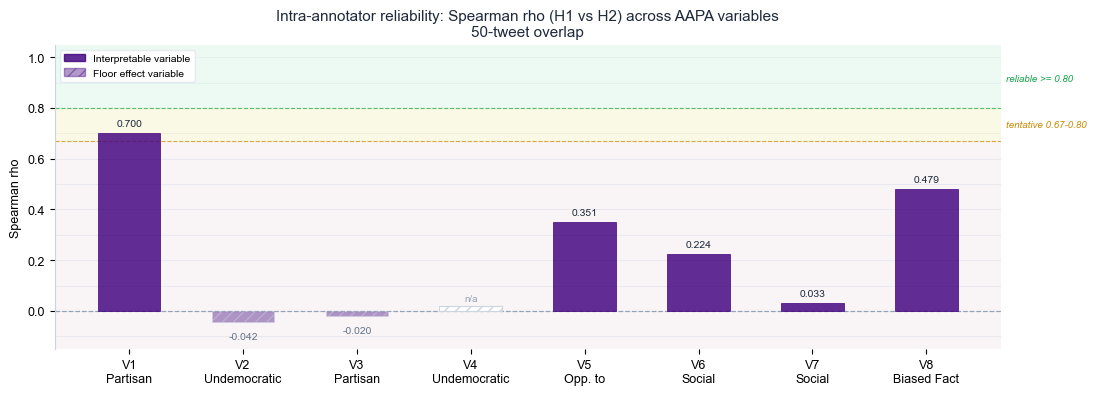

  Saved: study1/figures/figA2_intra_spearman_bars.png


In [16]:
rho_vals = intra_df["spearman_rho"].values

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

apply_zone_bands(ax, y_min=-0.15)

colour = "#3F007D"
for xi, (v, val) in enumerate(zip(SCORE_COLS, rho_vals)):
    is_fe = v in FLOOR_EFFECT_VARS
    if np.isnan(val):
        ax.bar(xi, 0.02, width=0.55, color="white", edgecolor="#CBD5E1",
               linewidth=0.8, hatch="///", zorder=2)
        ax.text(xi, 0.04, "n/a", ha="center", fontsize=7, color="#94A3B8")
        continue
    ax.bar(xi, val, width=0.55, color=colour,
           alpha=0.4 if is_fe else 0.82,
           hatch="///" if is_fe else "",
           edgecolor="#CBD5E1" if is_fe else colour,
           linewidth=0.6, zorder=2)
    label_y = val + 0.02 if val >= 0 else val - 0.04
    ax.text(xi, label_y, f"{val:.3f}", ha="center",
            va="bottom" if val >= 0 else "top", fontsize=7.5,
            color="#64748B" if is_fe else "#1E293B")

ax.axhline(THRESHOLD_HIGH, color="#16A34A", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.axhline(THRESHOLD_LOW,  color="#CA8A04", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.text(len(SCORE_COLS) - 0.3, 0.915, "reliable >= 0.80",
        fontsize=7, color="#16A34A", va="center", style="italic")
ax.text(len(SCORE_COLS) - 0.3, 0.735, "tentative 0.67-0.80",
        fontsize=7, color="#CA8A04", va="center", style="italic")
ax.set_ylim(-0.15, 1.05)
ax.set_ylabel("Spearman rho", fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.set_xticks(range(len(SCORE_COLS)))
ax.set_xticklabels(
    [f"{v}\n{VARIABLE_LABELS[v].split(chr(10))[1]}" for v in SCORE_COLS],
    fontsize=8, multialignment="center"
)
style_axes(ax)
handles = [
    mpatches.Patch(color=colour, alpha=0.82, label="Interpretable variable"),
    mpatches.Patch(color=colour, alpha=0.4, hatch="///",
                   edgecolor="#CBD5E1", label="Floor effect variable"),
]
ax.legend(handles=handles, fontsize=7.5, loc="upper left", framealpha=0.9, edgecolor="#E2E8F0")
ax.set_title("Intra-annotator reliability: Spearman rho (H1 vs H2) across AAPA variables\n50-tweet overlap",
             fontsize=11, color="#1E293B")
plt.tight_layout()
save_fig(fig, "figA2_intra_spearman_bars")


### Figure A3: Intra-Annotator Krippendorff's α Bar Chart

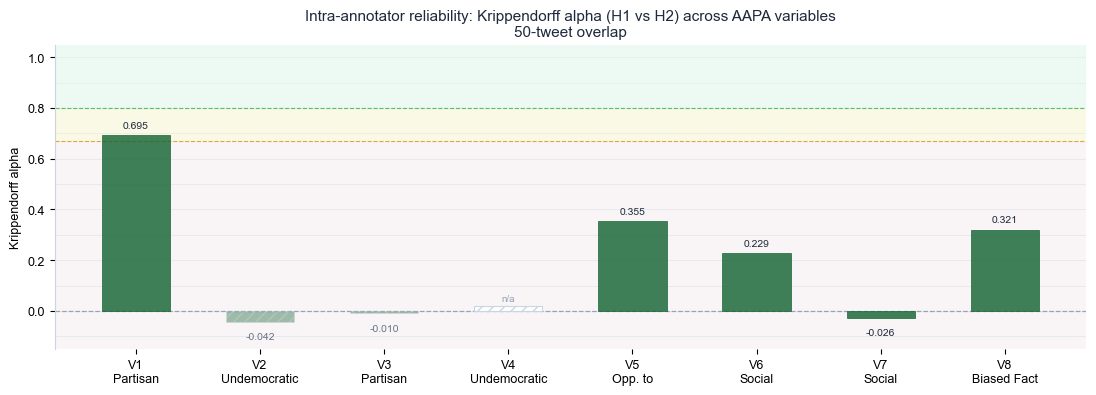

  Saved: study1/figures/figA3_intra_krippendorff_bars.png


In [17]:
alpha_vals = intra_df["krippendorff_alpha"].values

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

apply_zone_bands(ax, y_min=-0.15)

colour = "#166534"
for xi, (v, val) in enumerate(zip(SCORE_COLS, alpha_vals)):
    is_fe = v in FLOOR_EFFECT_VARS
    if np.isnan(val):
        ax.bar(xi, 0.02, width=0.55, color="white", edgecolor="#CBD5E1",
               linewidth=0.8, hatch="///", zorder=2)
        ax.text(xi, 0.04, "n/a", ha="center", fontsize=7, color="#94A3B8")
        continue
    ax.bar(xi, val, width=0.55, color=colour,
           alpha=0.4 if is_fe else 0.82,
           hatch="///" if is_fe else "",
           edgecolor="#CBD5E1" if is_fe else colour,
           linewidth=0.6, zorder=2)
    label_y = val + 0.02 if val >= 0 else val - 0.04
    ax.text(xi, label_y, f"{val:.3f}", ha="center",
            va="bottom" if val >= 0 else "top", fontsize=7.5,
            color="#64748B" if is_fe else "#1E293B")

ax.axhline(THRESHOLD_HIGH, color="#16A34A", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.axhline(THRESHOLD_LOW,  color="#CA8A04", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
ax.set_ylim(-0.15, 1.05)
ax.set_ylabel("Krippendorff alpha", fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.set_xticks(range(len(SCORE_COLS)))
ax.set_xticklabels(
    [f"{v}\n{VARIABLE_LABELS[v].split(chr(10))[1]}" for v in SCORE_COLS],
    fontsize=8, multialignment="center"
)
style_axes(ax)
ax.set_title("Intra-annotator reliability: Krippendorff alpha (H1 vs H2) across AAPA variables\n50-tweet overlap",
             fontsize=11, color="#1E293B")
plt.tight_layout()
save_fig(fig, "figA3_intra_krippendorff_bars")


---
## Section B: Inter-Annotator Agreement

Evaluates agreement between human annotators and LLMs across all pairwise combinations.
Primary comparison: does human-LLM agreement approach human-human (H1 vs H2) consistency?

**Metrics:** Krippendorff's alpha (ordinal), Spearman's rho, MAD
V2, V3, V4 excluded from substantive interpretation due to floor effect.


### B1. Compute Pairwise Metrics

In [18]:
human_labels = ["Human P1", "Human P2"]
llm_labels   = list(llm_mats.keys())

all_pairs = (
    [("Human P1", "Human P2")]
    + [(h, l) for h in human_labels for l in llm_labels]
    + list(combinations(llm_labels, 2))
)

inter_records = []
for label_a, label_b in all_pairs:
    mat_a = annotators[label_a]
    mat_b = annotators[label_b]
    for v in SCORE_COLS:
        a = mat_a[v].values
        b = mat_b[v].values
        rho, pval = spearman_rho(a, b)
        mad       = mean_abs_deviation(a, b)
        inter_records.append({
            "annotator_A":  label_a,
            "annotator_B":  label_b,
            "pairing":      f"{label_a} vs {label_b}",
            "variable":     v,
            "spearman_rho": round(rho, 3),
            "spearman_p":   round(pval, 4),
            "MAD":          round(mad, 3),
        })

inter_df = pd.DataFrame(inter_records)
inter_df.to_csv(os.path.join(OUTPUT_DIR, "sectionB_inter_annotator.csv"), index=False)
print(f"Computed {len(inter_df)} pairing x variable combinations")


Computed 80 pairing x variable combinations


### Table B2: Spearman ρ

In [19]:
rho_pivot = inter_df.pivot_table(
    index="pairing", columns="variable", values="spearman_rho"
)[SCORE_COLS]
display(rho_pivot.round(3))


variable,V1,V2,V3,V4,V5,V6,V7,V8
pairing,,,,,,,,
GPT-4o vs Claude Sonnet,0.793,0.316,NaN,0.489,0.581,0.687,0.808,0.654
GPT-4o vs Llama 3.1-8B,0.616,0.273,0.354,0.506,0.392,0.538,0.615,0.548
Human P1 vs Claude Sonnet,0.569,-0.183,NaN,NaN,0.387,0.336,-0.003,0.242
Human P1 vs GPT-4o,0.437,0.021,-0.020,NaN,0.208,0.266,0.177,0.342
Human P1 vs Human P2,0.700,-0.042,-0.020,NaN,0.351,0.224,0.033,0.479
Human P1 vs Llama 3.1-8B,0.472,-0.138,-0.058,NaN,0.163,0.071,-0.148,0.159
Human P2 vs Claude Sonnet,0.628,0.215,NaN,NaN,0.687,0.423,0.582,0.295
Human P2 vs GPT-4o,0.671,0.269,-0.020,NaN,0.475,0.406,0.540,0.288
Human P2 vs Llama 3.1-8B,0.694,0.319,0.354,NaN,0.379,0.178,0.295,0.107


### Table B3: MAD 

In [20]:
mad_pivot = inter_df.pivot_table(
    index="pairing", columns="variable", values="MAD"
)[SCORE_COLS]
display(mad_pivot.round(3))


variable,V1,V2,V3,V4,V5,V6,V7,V8
pairing,,,,,,,,
GPT-4o vs Claude Sonnet,0.26,0.30,0.02,0.06,0.24,0.30,0.32,0.58
GPT-4o vs Llama 3.1-8B,0.44,0.38,0.26,0.24,0.40,0.36,0.22,0.32
Human P1 vs Claude Sonnet,0.44,0.40,0.02,0.06,0.38,0.48,0.66,0.82
Human P1 vs GPT-4o,0.54,0.26,0.04,0.04,0.46,0.46,0.34,0.40
Human P1 vs Human P2,0.32,0.10,0.04,0.00,0.40,0.38,0.46,0.44
Human P1 vs Llama 3.1-8B,0.54,0.40,0.30,0.28,0.38,0.50,0.36,0.56
Human P2 vs Claude Sonnet,0.40,0.30,0.02,0.06,0.22,0.42,0.36,0.62
Human P2 vs GPT-4o,0.38,0.20,0.04,0.04,0.30,0.36,0.28,0.48
Human P2 vs Llama 3.1-8B,0.34,0.30,0.26,0.28,0.34,0.48,0.42,0.56


### B2. Krippendorff's α: Pairwise and Multi-Annotator Subsets

Thresholds: alpha >= 0.80 reliable; alpha >= 0.67 tentative; alpha < 0.67 below threshold.


In [21]:
alpha_sets = {
    "All annotators":               list(annotators.values()),
    "Humans only (H1, H2)":         [h1_mat, h2_mat],
    "LLMs only (3 models)":         list(llm_mats.values()),
    "H1 + GPT-4o":                  [h1_mat, llm_mats.get("GPT-4o")],
    "H1 + Claude Sonnet":           [h1_mat, llm_mats.get("Claude Sonnet")],
    "H1 + Llama 3.1-8B":            [h1_mat, llm_mats.get("Llama 3.1-8B")],
    "H2 + GPT-4o":                  [h2_mat, llm_mats.get("GPT-4o")],
    "H2 + Claude Sonnet":           [h2_mat, llm_mats.get("Claude Sonnet")],
    "H2 + Llama 3.1-8B":            [h2_mat, llm_mats.get("Llama 3.1-8B")],
    "GPT-4o + Claude Sonnet":       [llm_mats.get("GPT-4o"), llm_mats.get("Claude Sonnet")],
    "GPT-4o + Llama 3.1-8B":        [llm_mats.get("GPT-4o"), llm_mats.get("Llama 3.1-8B")],
    "Claude Sonnet + Llama 3.1-8B": [llm_mats.get("Claude Sonnet"), llm_mats.get("Llama 3.1-8B")],
}

alpha_records = []
for label, matrices in alpha_sets.items():
    matrices = [m for m in matrices if m is not None]
    if len(matrices) < 2:
        continue
    row = {"annotator_set": label}
    for v in SCORE_COLS:
        row[v] = round(krippendorff_alpha(matrices, v), 3)
    alpha_records.append(row)

alpha_df = pd.DataFrame(alpha_records).set_index("annotator_set")
alpha_df.to_csv(os.path.join(OUTPUT_DIR, "sectionB_krippendorff_alpha.csv"))


### Table B4: Krippendorff's α  All Annotator Subsets

In [23]:
display(alpha_df.round(3))


,V1,V2,V3,V4,V5,V6,V7,V8
annotator_set,,,,,,,,
All annotators,0.596,0.158,0.065,0.192,0.360,0.353,0.340,0.305
"Humans only (H1, H2)",0.695,-0.042,-0.010,NaN,0.355,0.229,-0.026,0.321
LLMs only (3 models),0.661,0.410,0.077,0.405,0.338,0.552,0.561,0.484
H1 + GPT-4o,0.339,-0.009,-0.010,-0.010,0.205,0.229,0.139,0.306
H1 + Claude Sonnet,0.551,-0.206,0.000,-0.010,0.373,0.250,-0.073,-0.036
H1 + Llama 3.1-8B,0.442,-0.137,-0.076,-0.065,0.078,0.079,-0.137,0.080
H2 + GPT-4o,0.603,0.062,-0.010,-0.010,0.474,0.376,0.528,0.256
H2 + Claude Sonnet,0.628,-0.015,0.000,-0.010,0.676,0.350,0.570,0.232
H2 + Llama 3.1-8B,0.676,0.111,0.176,-0.065,0.213,0.185,0.218,0.110


---
## Section C: Distributional and Error Analysis

Identifies systematic patterns in annotation beyond point estimates of agreement.
Distinguishes random disagreement from threshold differences and model-level scoring biases.


### C1. Score Drift (H1 → H2)

In [25]:
# Compute per-tweet, per-variable drift (H1 - H2)
# mean_drift column = Mean Signed Drift (MSD): positive = H1 higher, negative = H2 higher
drift_rows = []
for tid in common_ids:
    row = {"tweet_id": tid}
    for v in SCORE_COLS:
        row[f"{v}_H1"]    = h1_mat.loc[tid, v]
        row[f"{v}_H2"]    = h2_mat.loc[tid, v]
        row[f"{v}_drift"] = int(h1_mat.loc[tid, v]) - int(h2_mat.loc[tid, v])
    drift_rows.append(row)

drift_df = pd.DataFrame(drift_rows)
drift_df.to_csv(os.path.join(OUTPUT_DIR, "score_drift.csv"), index=False)

print(f"{'Variable':<6} {'MSD (H1-H2)':>12} {'Higher in P2':>14} {'Same':>6} {'Lower in P2':>12}")
print("-" * 55)
for v in SCORE_COLS:
    col  = f"{v}_drift"
    up   = (drift_df[col] > 0).sum()   # H1 higher = P2 lower
    same = (drift_df[col] == 0).sum()
    down = (drift_df[col] < 0).sum()   # H1 lower = P2 higher
    mean = drift_df[col].mean()
    print(f"{v:<6} {mean:>+12.3f} {up:>14} {same:>6} {down:>12}")


Variable  MSD (H1-H2)   Higher in P2   Same  Lower in P2
-------------------------------------------------------
V1           +0.080             10     35            5
V2           +0.060              4     45            1
V3           +0.000              1     48            1
V4           +0.000              0     50            0
V5           +0.000              9     31           10
V6           -0.020              8     32           10
V7           -0.260              5     29           16
V8           -0.400              1     30           19


### C2. Spread Map

Each point = one tweet.
- x-axis: mean total AAPA score across all five annotators
- y-axis: max minus min total score across annotators (annotator spread)
Dotted lines indicate dataset medians. Case study tweets are labelled.


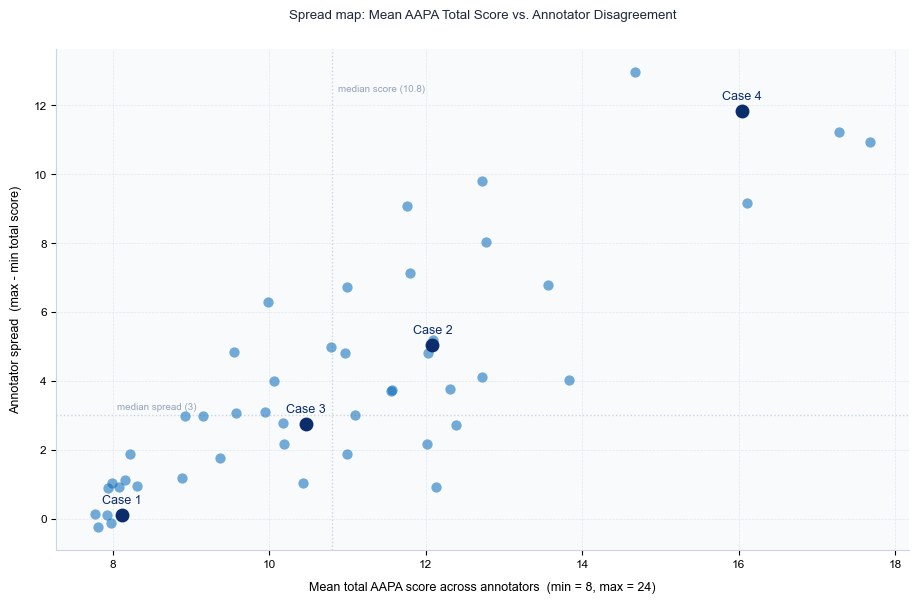

  Saved: study1/figures/figC2_spread_map.png


In [26]:
all_annotators_map = {"Human P1": h1_mat, "Human P2": h2_mat}
all_annotators_map.update({k: v for k, v in llm_mats.items() if v is not None})

spread_records = []
for tid in common_ids:
    scores = []
    for label, mat in all_annotators_map.items():
        if tid in mat.index:
            s = mat.loc[tid, SCORE_COLS].sum()
            scores.append(float(s))
    if len(scores) >= 2:
        spread_records.append({
            "tweet_id":   tid,
            "mean_score": np.mean(scores),
            "spread":     max(scores) - min(scores),
        })

spread_df = pd.DataFrame(spread_records).reset_index(drop=True)

rng = np.random.default_rng(42)
jx  = rng.uniform(-0.3, 0.3, len(spread_df))
jy  = rng.uniform(-0.3, 0.3, len(spread_df))

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8FAFC")
ax.grid(True, linestyle="--", linewidth=0.5, color="#E2E8F0", zorder=0)
ax.set_axisbelow(True)

med_x = spread_df["mean_score"].median()
med_y = spread_df["spread"].median()
ax.axvline(med_x, color="#CBD5E1", linewidth=1.0, linestyle=":", zorder=1)
ax.axhline(med_y, color="#CBD5E1", linewidth=1.0, linestyle=":", zorder=1)
ax.text(med_x + 0.08, spread_df["spread"].max() * 0.97,
        f"median score ({med_x:.1f})", fontsize=7, color="#94A3B8", va="top")
ax.text(spread_df["mean_score"].min() + 0.05, med_y + 0.18,
        f"median spread ({med_y:.0f})", fontsize=7, color="#94A3B8")

ax.scatter(spread_df["mean_score"] + jx, spread_df["spread"] + jy,
           s=55, color="#0569B9", alpha=0.55, linewidths=0, zorder=2)

case_labels = {"208": "Case 1", "254": "Case 2", "91": "Case 3", "428": "Case 4"}
for tid, label in case_labels.items():
    matches = spread_df.index[spread_df["tweet_id"] == tid]
    if len(matches) == 0:
        continue
    i = matches[0]
    x = spread_df.loc[i, "mean_score"] + jx[i]
    y = spread_df.loc[i, "spread"]     + jy[i]
    ax.scatter(x, y, s=100, color="#0C2D6B", linewidths=0, zorder=4)
    ax.text(x, y + 0.25, label, fontsize=9, color="#0C2D6B",
            ha="center", va="bottom", zorder=5)

ax.set_xlabel("Mean total AAPA score across annotators  (min = 8, max = 24)",
              fontsize=9, labelpad=8)
ax.set_ylabel("Annotator spread  (max - min total score)", fontsize=9, labelpad=8)
ax.tick_params(labelsize=8.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_color("#CBD5E1")
ax.set_title("Spread map: Mean AAPA Total Score vs. Annotator Disagreement\n",
             fontsize=9.5, pad=12, color="#1E293B")
save_fig(fig, "figC2_spread_map")


---
## Reliability Summary Table


In [27]:
def get_rho(a, b, v):
    row = inter_df[
        (inter_df["annotator_A"] == a) &
        (inter_df["annotator_B"] == b) &
        (inter_df["variable"] == v)
    ]
    return row["spearman_rho"].values[0] if not row.empty else np.nan


def get_alpha(label, v):
    row = alpha_df[alpha_df.index == label]
    return row[v].values[0] if not row.empty else np.nan


summary_rows = []
for v in SCORE_COLS:
    summary_rows.append({
        "Variable":            v,
        "rho (H1-H2)":         get_rho("Human P1", "Human P2", v),
        "MAD (H1-H2)":         intra_df.loc[v, "MAD"],
        "MSD (H1-H2)":         intra_df.loc[v, "mean_drift_H1-H2"],
        "alpha (all)":         get_alpha("All annotators", v),
        "alpha (LLMs only)":   get_alpha("LLMs only (3 models)", v),
        "alpha (humans only)": get_alpha("Humans only (H1, H2)", v),
        "floor_effect":        v in FLOOR_EFFECT_VARS,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Variable").round(3)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "reliability_summary.csv"))
display(summary_df)


,rho (H1-H2),MAD (H1-H2),MSD (H1-H2),alpha (all),alpha (LLMs only),alpha (humans only),floor_effect
Variable,,,,,,,
V1,0.700,0.32,0.08,0.596,0.661,0.695,False
V2,-0.042,0.10,0.06,0.158,0.410,-0.042,True
V3,-0.020,0.04,0.00,0.065,0.077,-0.010,True
V4,NaN,0.00,0.00,0.192,0.405,NaN,True
V5,0.351,0.40,0.00,0.360,0.338,0.355,False
V6,0.224,0.38,-0.02,0.353,0.552,0.229,False
V7,0.033,0.46,-0.26,0.340,0.561,-0.026,False
V8,0.479,0.44,-0.40,0.305,0.484,0.321,False


---
## Visualisations

Design language:
- Green / yellow / red bands encode reliability zones (>= 0.80, 0.67-0.80, < 0.67)
- Floor effect variables (V2, V3, V4) flagged with hatching


### Figure 1: Krippendorff's α Grouped Bar Chart by Annotator Subset

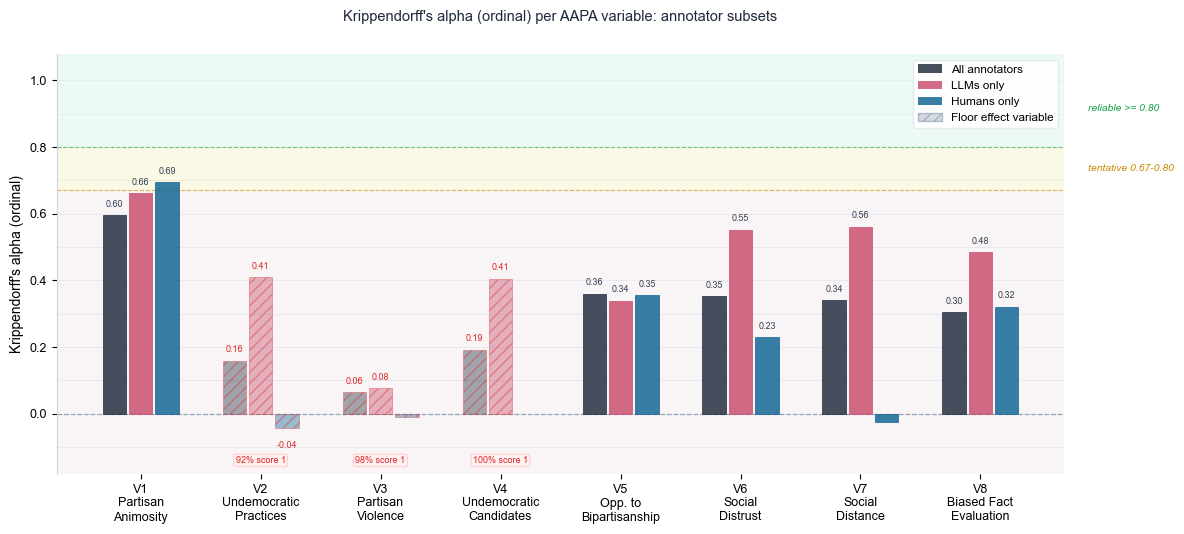

  Saved: study1/figures/fig1_krippendorff_barchart.png


In [28]:
DOT_SETS = {
    "All annotators": list(annotators.values()),
    "LLMs only":      list(llm_mats.values()),
    "Humans only":    [h1_mat, h2_mat],
}
DOT_COLOURS = {
    "All annotators": "#1E293B",
    "LLMs only":      "#C94A6B",
    "Humans only":    "#0C6291",
}

alpha_vals_grouped = {}
for aset, matrices in DOT_SETS.items():
    matrices = [m for m in matrices if m is not None]
    alpha_vals_grouped[aset] = {v: krippendorff_alpha(matrices, v) for v in SCORE_COLS}

n_sets = len(DOT_SETS)
bar_w  = 0.22
x      = np.arange(len(SCORE_COLS))

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

apply_zone_bands(ax, y_min=-0.18)
ax.axhline(THRESHOLD_LOW,  color="#CA8A04", linewidth=0.8, linestyle="--", zorder=1, alpha=0.6)
ax.axhline(THRESHOLD_HIGH, color="#16A34A", linewidth=0.8, linestyle="--", zorder=1, alpha=0.6)

for si, (aset, colour) in enumerate(DOT_COLOURS.items()):
    offsets = x + (si - 1) * bar_w
    for xi, v in enumerate(SCORE_COLS):
        val   = alpha_vals_grouped[aset][v]
        is_fe = v in FLOOR_EFFECT_VARS
        if np.isnan(val):
            continue
        ax.bar(offsets[xi], val, width=bar_w * 0.88, color=colour,
               alpha=0.4 if is_fe else 0.82,
               hatch="///" if is_fe else "",
               edgecolor="#DC2626" if is_fe else colour,
               linewidth=0.6, zorder=2,
               label=aset if xi == 0 else "")
        if abs(val) > 0.03:
            label_y = val + 0.02 if val >= 0 else val - 0.04
            ax.text(offsets[xi], label_y, f"{val:.2f}", fontsize=6.5,
                    ha="center", va="bottom" if val >= 0 else "top",
                    color="#DC2626" if is_fe else "#334155")

for xi, v in enumerate(SCORE_COLS):
    if v in FLOOR_EFFECT_VARS:
        ax.text(x[xi], -0.14, FLOOR_EFFECT_NOTES[v], fontsize=6.5,
                color="#DC2626", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="#FFF1F2",
                          edgecolor="#FECACA", linewidth=0.7))

ax.text(len(SCORE_COLS) - 0.1, 0.915, "reliable >= 0.80",
        fontsize=7.5, color="#16A34A", va="center", style="italic")
ax.text(len(SCORE_COLS) - 0.1, 0.735, "tentative 0.67-0.80",
        fontsize=7.5, color="#CA8A04", va="center", style="italic")

ax.set_xticks(x)
ax.set_xticklabels([VARIABLE_LABELS[v] for v in SCORE_COLS],
                   fontsize=8, multialignment="center")
ax.set_ylim(-0.18, 1.08)
ax.set_ylabel("Krippendorff's alpha (ordinal)", fontsize=10)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
style_axes(ax)

legend_handles = [
    mpatches.Patch(facecolor=DOT_COLOURS[a], alpha=0.82, label=a) for a in DOT_SETS
]
legend_handles.append(
    mpatches.Patch(facecolor="#94A3B8", alpha=0.4, hatch="///",
                   edgecolor="#64748B", label="Floor effect variable")
)
ax.legend(handles=legend_handles, fontsize=8.5, loc="upper right",
          framealpha=0.9, edgecolor="#E2E8F0")
ax.set_title("Krippendorff's alpha (ordinal) per AAPA variable: annotator subsets\n",
             fontsize=10.5, pad=12, color="#1E293B")
plt.subplots_adjust(bottom=0.18)
save_fig(fig, "fig1_krippendorff_barchart")


### Figure 2b/2c: Agreement Matrices (Spearman ρ and Krippendorff's α)

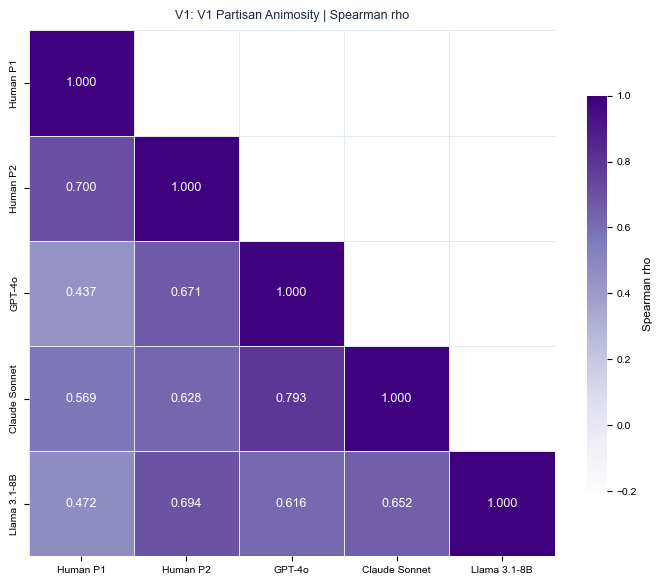

  Saved: study1/figures/fig2b_spearman_v1.png


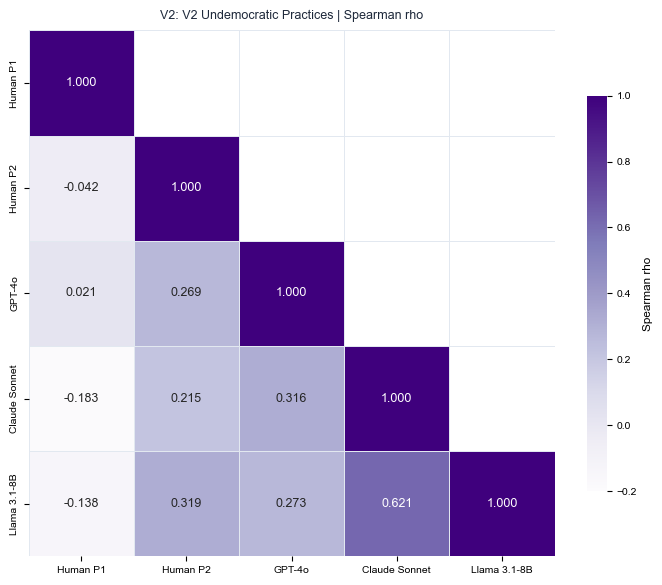

  Saved: study1/figures/fig2b_spearman_v2.png


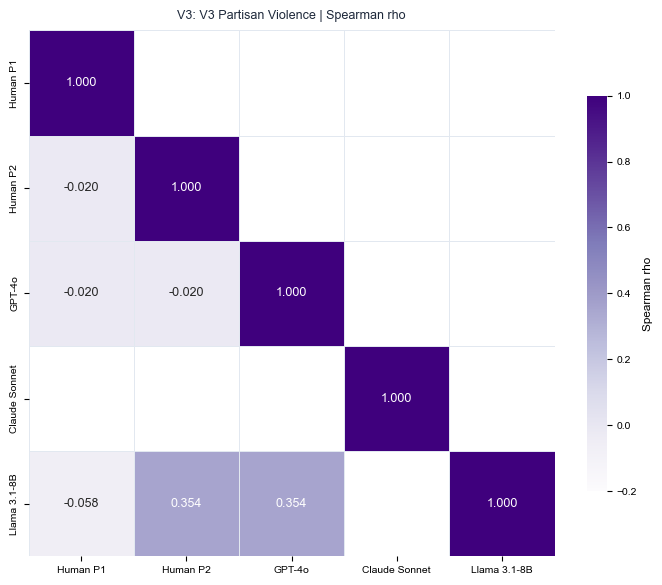

  Saved: study1/figures/fig2b_spearman_v3.png


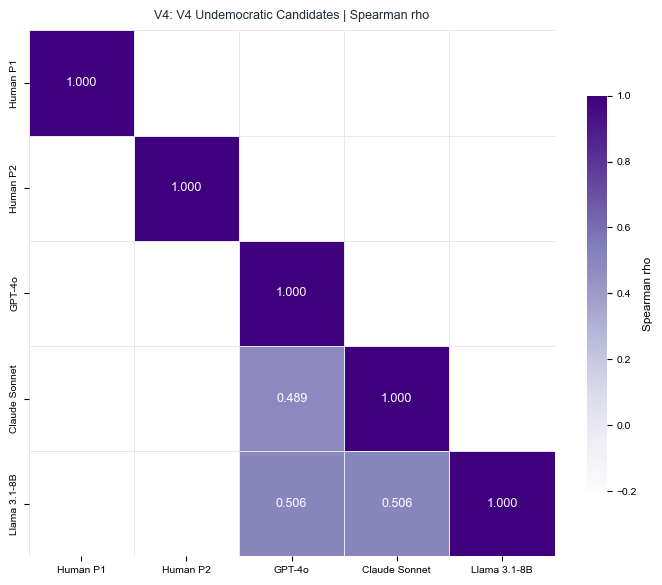

  Saved: study1/figures/fig2b_spearman_v4.png


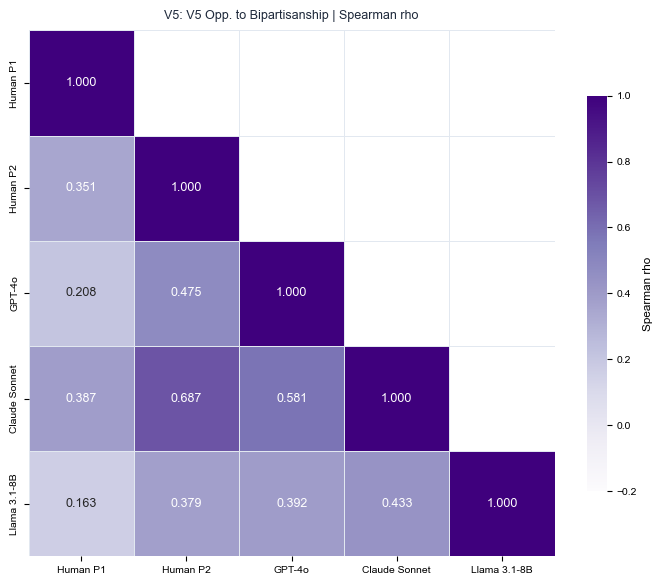

  Saved: study1/figures/fig2b_spearman_v5.png


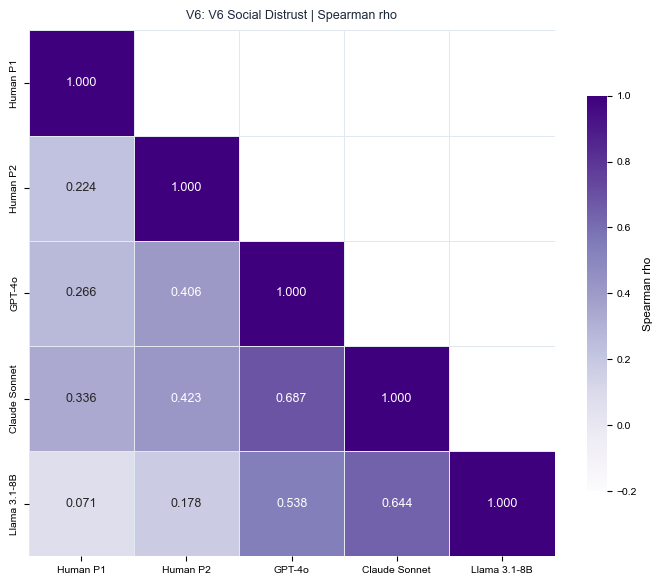

  Saved: study1/figures/fig2b_spearman_v6.png


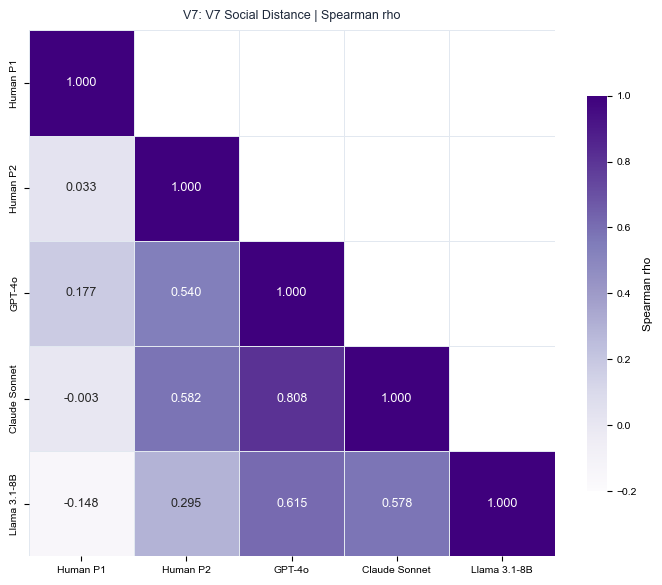

  Saved: study1/figures/fig2b_spearman_v7.png


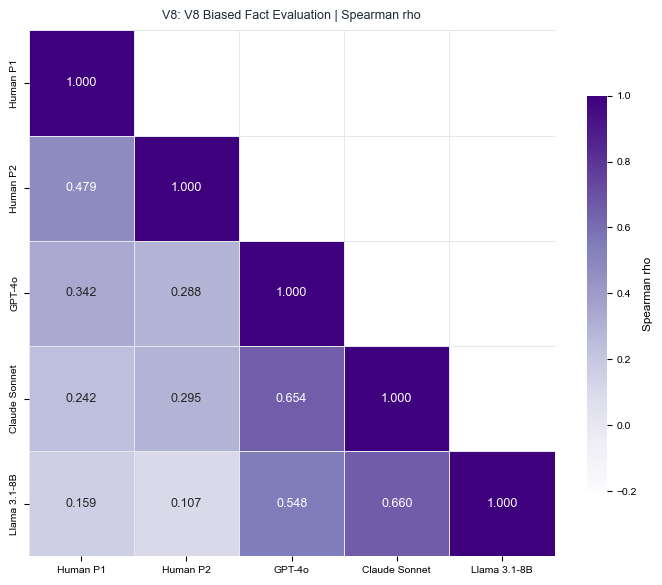

  Saved: study1/figures/fig2b_spearman_v8.png


In [30]:
# Build annotator x annotator agreement matrix for a given variable and metric
def build_agreement_matrix(variable, metric, source_df):
    mat = pd.DataFrame(np.nan, index=ANNOTATOR_ORDER, columns=ANNOTATOR_ORDER)
    for a in ANNOTATOR_ORDER:
        mat.loc[a, a] = 1.0
    for _, row in source_df[source_df["variable"] == variable].iterrows():
        a, b = row["annotator_A"], row["annotator_B"]
        if a in ANNOTATOR_ORDER and b in ANNOTATOR_ORDER:
            mat.loc[a, b] = row[metric]
            mat.loc[b, a] = row[metric]
    return mat


def plot_agreement_matrices(metric, metric_label, stem, source_df, cmap_normal="Blues"):
    for v in SCORE_COLS:
       
        mat   = build_agreement_matrix(v, metric, source_df)
        mask  = np.triu(np.ones_like(mat.values, dtype=bool), k=1)
        arr   = mat.copy().astype(float).values.copy()
        arr[mask] = np.nan
        mat_masked = pd.DataFrame(arr, index=mat.index, columns=mat.columns)

        fig, ax = plt.subplots(figsize=(7, 6))
        fig.patch.set_facecolor("white")
        cmap = cmap_normal
        sns.heatmap(mat_masked, annot=True, fmt=".3f", cmap=cmap,
                    vmin=-0.2, vmax=1.0, ax=ax, square=True,
                    linewidths=0.5, linecolor="#E2E8F0",
                    annot_kws={"size": 9},
                    cbar_kws={"shrink": 0.7, "label": metric_label})
        title = f"{v}: {VARIABLE_LABELS[v].replace(chr(10), ' ')} | {metric_label}"
        ax.set_title(title, fontsize=9, pad=8, color="#1E293B")
        plt.tight_layout()
        save_fig(fig, f"{stem}_{v.lower()}")


plot_agreement_matrices("spearman_rho", "Spearman rho", "fig2b_spearman", inter_df, cmap_normal="Purples")


### Figure 3: Score Drift Strip Plot (H1 vs H2)

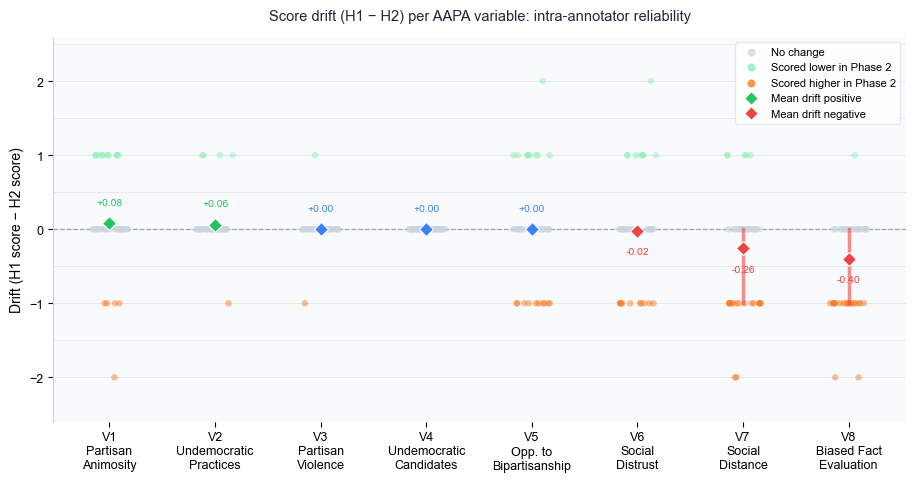

  Saved: study1/figures/fig3_drift_plot.png


In [33]:
drift_df     = pd.read_csv(os.path.join(OUTPUT_DIR, "score_drift.csv"))
drift_melted = (
    drift_df[[f"{v}_drift" for v in SCORE_COLS]]
    .rename(columns={f"{v}_drift": v for v in SCORE_COLS})
    .melt(var_name="variable", value_name="drift")
)

COLOUR_SAME = "#CBD5E1"
COLOUR_POS  = "#86EFAC"
COLOUR_NEG  = "#F97316"

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

for y in np.arange(-2, 3, 0.5):
    ax.axhline(y, color="#E2E8F0", linewidth=0.6, zorder=0)
ax.axhline(0, color="#94A3B8", linewidth=0.9, linestyle="--", zorder=1)

rng = np.random.default_rng(42)
for xi, v in enumerate(SCORE_COLS):
    vals   = drift_melted[drift_melted["variable"] == v]["drift"].values
    jitter = rng.uniform(-0.18, 0.18, size=len(vals))
    dot_colours = [
        COLOUR_POS if d > 0 else COLOUR_NEG if d < 0 else COLOUR_SAME for d in vals
    ]
    ax.scatter(xi + jitter, vals, color=dot_colours, alpha=0.45, s=22, zorder=3, linewidths=0)

    mean_val    = vals.mean()
    mean_colour = "#22C55E" if mean_val > 0.01 else "#EF4444" if mean_val < -0.01 else "#3B82F6"
    ax.plot(xi, mean_val, marker="D", markersize=7, color=mean_colour, zorder=5,
            markeredgecolor="white", markeredgewidth=0.8)
    q25, q75 = np.percentile(vals, [25, 75])
    ax.plot([xi, xi], [q25, q75], color=mean_colour, linewidth=2.5, alpha=0.6, zorder=4)
    offset = 0.22 if mean_val >= 0 else -0.22
    ax.text(xi, mean_val + offset, f"{mean_val:+.2f}", fontsize=7.5,
            ha="center", va="bottom" if mean_val >= 0 else "top",
            color=mean_colour, fontweight="500")

ax.set_xticks(np.arange(len(SCORE_COLS)))
ax.set_xticklabels([VARIABLE_LABELS[v] for v in SCORE_COLS],
                   fontsize=7, rotation=0, ha="center", multialignment="center")
ax.set_ylabel("Drift (H1 score − H2 score)", fontsize=10)
ax.set_ylim(-2.6, 2.6)
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
style_axes(ax)

legend_handles = [
    plt.scatter([], [], color=COLOUR_SAME, alpha=0.7, s=22, label="No change"),
    plt.scatter([], [], color=COLOUR_POS,  alpha=0.7, s=22, label="Scored lower in Phase 2"),
    plt.scatter([], [], color=COLOUR_NEG,  alpha=0.7, s=22, label="Scored higher in Phase 2"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="#22C55E",
               markersize=7, label="Mean drift positive"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="#EF4444",
               markersize=7, label="Mean drift negative"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="upper right",
          framealpha=0.9, edgecolor="#E2E8F0")
ax.set_title("Score drift (H1 − H2) per AAPA variable: intra-annotator reliability",
             fontsize=10.5, pad=12, color="#1E293B")
save_fig(fig, "fig3_drift_plot")

### Figure 3a: Score-Level Agreement Bar Chart (H1 vs H2)

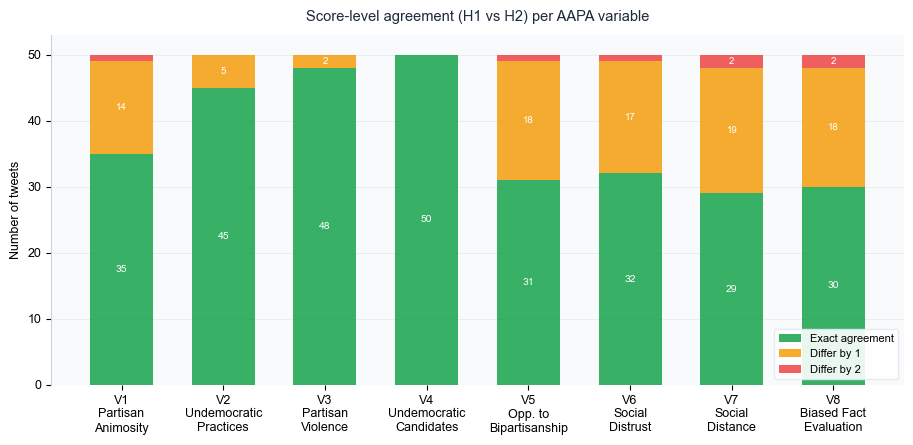

  Saved: study1/figures/fig3a_score_level_agreement.png


In [37]:
agree_exact = np.array([int(np.sum(np.abs(h1_mat[v].values - h2_mat[v].values) == 0)) for v in SCORE_COLS])
agree_one   = np.array([int(np.sum(np.abs(h1_mat[v].values - h2_mat[v].values) == 1)) for v in SCORE_COLS])
agree_two   = np.array([int(np.sum(np.abs(h1_mat[v].values - h2_mat[v].values) == 2)) for v in SCORE_COLS])
n_tweets    = len(h1_mat)
xi          = np.arange(len(SCORE_COLS))
bar_w       = 0.62

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")
for y in np.arange(0, n_tweets + 1, 10):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

ax.bar(xi, agree_exact, width=bar_w, color="#16A34A", alpha=0.85, label="Exact agreement", zorder=2)
ax.bar(xi, agree_one,   width=bar_w, bottom=agree_exact, color="#F59E0B", alpha=0.85, label="Differ by 1", zorder=2)
ax.bar(xi, agree_two,   width=bar_w, bottom=agree_exact + agree_one, color="#EF4444", alpha=0.85, label="Differ by 2", zorder=2)

for i in range(len(SCORE_COLS)):
    ax.text(xi[i], agree_exact[i] / 2, str(agree_exact[i]),
            ha="center", va="center", fontsize=7.5, color="white", fontweight="500")
    if agree_one[i] >= 2:
        ax.text(xi[i], agree_exact[i] + agree_one[i] / 2, str(agree_one[i]),
                ha="center", va="center", fontsize=7, color="white", fontweight="500")
    if agree_two[i] >= 2:
        ax.text(xi[i], agree_exact[i] + agree_one[i] + agree_two[i] / 2, str(agree_two[i]),
                ha="center", va="center", fontsize=7, color="white", fontweight="500")

ax.set_xticks(xi)
ax.set_xticklabels([VARIABLE_LABELS[v] for v in SCORE_COLS], fontsize=7.5, multialignment="center")
ax.set_ylim(0, n_tweets + 3)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.set_ylabel("Number of tweets", fontsize=9)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9, edgecolor="#E2E8F0")
style_axes(ax)
ax.set_title("Score-level agreement (H1 vs H2) per AAPA variable",
             fontsize=10.5, pad=10, color="#1E293B")
plt.subplots_adjust(bottom=0.18)
save_fig(fig, "fig3a_score_level_agreement")

### Figure 3b: Total Score Divergence Histogram (H1 vs H2)

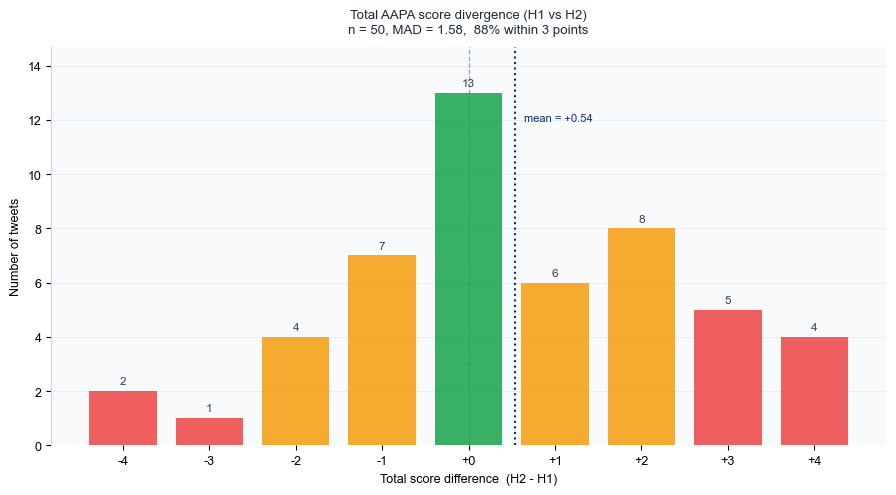

  Saved: study1/figures/fig3b_total_score_divergence_h1_h2.png


In [38]:
h1_totals   = h1_mat[SCORE_COLS].sum(axis=1)
h2_totals   = h2_mat[SCORE_COLS].sum(axis=1)
diff        = (h2_totals - h1_totals).values   # positive = H2 scored higher
n_valid     = len(diff)
mean_diff   = diff.mean()
mean_abs    = np.abs(diff).mean()
pct_within3 = 100 * (np.abs(diff) <= 3).mean()

bins   = np.arange(-4, 6) - 0.5
xticks = np.arange(-4, 5)
counts, _ = np.histogram(diff, bins=bins)

def bar_colour(x):
    if x == 0:      return "#16A34A"
    if abs(x) <= 2: return "#F59E0B"
    return "#EF4444"

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8FAFC")
for y in np.arange(0, counts.max() + 2, 2):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)
ax.axvline(0, color="#94A3B8", linewidth=0.9, linestyle="--", zorder=1)

for centre, count in zip(xticks, counts):
    ax.bar(centre, count, width=0.78, color=bar_colour(centre), alpha=0.85, zorder=2)
    if count > 0:
        ax.text(centre, count + 0.25, str(count), ha="center", fontsize=8.5, color="#334155")

ax.axvline(mean_diff, color="#0C2D6B", linewidth=1.5, linestyle=":", zorder=3)
ax.text(mean_diff + 0.1, counts.max() * 0.92, f"mean = {mean_diff:+.2f}",
        fontsize=8, color="#0C2D6B")

ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:+d}" for x in xticks], fontsize=9)
ax.set_xlabel("Total score difference  (H2 - H1)", fontsize=9)
ax.set_ylabel("Number of tweets", fontsize=9)
style_axes(ax)
ax.set_title(
    f"Total AAPA score divergence (H1 vs H2)\n"
    f"n = {n_valid}, MAD = {mean_abs:.2f},  {pct_within3:.0f}% within 3 points",
    fontsize=9.5, pad=10, color="#1E293B"
)
plt.tight_layout()
save_fig(fig, "fig3b_total_score_divergence_h1_h2")


### Figure 4: Score Distributions All Annotators

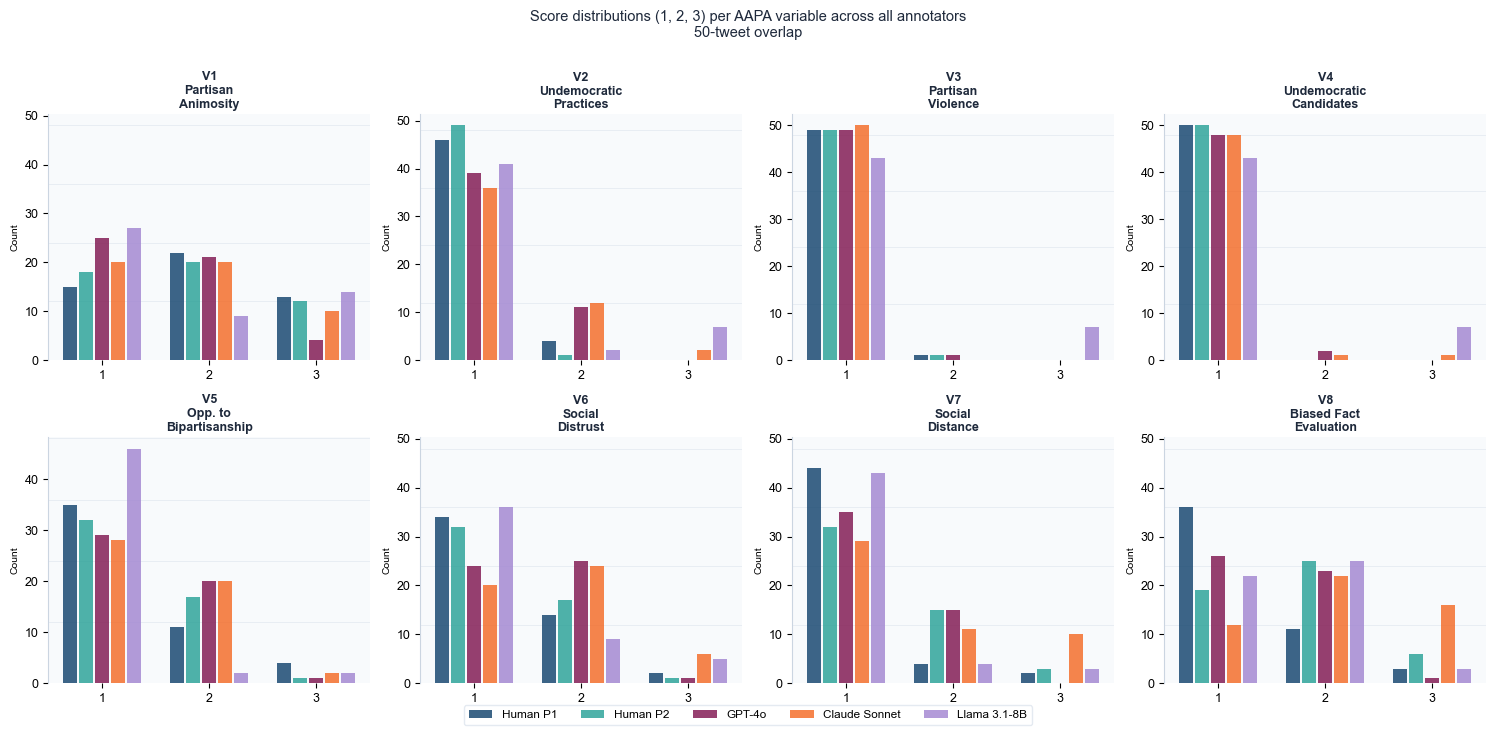

  Saved: study1/figures/fig4_score_distributions.png


In [39]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=False)
axes = axes.flatten()
fig.patch.set_facecolor("white")
bar_w = 0.75 / len(ANNOTATOR_ORDER)

for i, v in enumerate(SCORE_COLS):
    ax = axes[i]
    ax.set_facecolor("#F8FAFC")
    for j, label in enumerate(ANNOTATOR_ORDER):
        counts = (
            annotators[label][v]
            .value_counts()
            .reindex([1, 2, 3], fill_value=0)
        )
        offset = (j - len(ANNOTATOR_ORDER) / 2 + 0.5) * bar_w
        ax.bar(np.array([1, 2, 3]) + offset, counts.values,
               width=bar_w * 0.88, color=PALETTE[label], alpha=0.82,
               label=label if i == 0 else "", zorder=2)
    n_t = len(annotators[ANNOTATOR_ORDER[0]][v])
    for y in np.arange(0, n_t + 1, max(1, n_t // 4)):
        ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)
    ax.set_title(f"{VARIABLE_LABELS[v]}", fontsize=9, fontweight="bold",
                 pad=4, color="#1E293B")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["1", "2", "3"], fontsize=8)
    ax.set_ylabel("Count", fontsize=7.5)
    style_axes(ax)

fig.legend(loc="lower center", ncol=len(ANNOTATOR_ORDER), fontsize=8.5,
           framealpha=0.9, edgecolor="#E2E8F0", bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Score distributions (1, 2, 3) per AAPA variable across all annotators\n50-tweet overlap",
             fontsize=10.5, y=1.01, color="#1E293B")
plt.tight_layout()
save_fig(fig, "fig4_score_distributions")


---
## Run Summary

In [40]:
print("Study 1 analysis complete")
print(f"  CSVs:    ./{OUTPUT_DIR}/")
print(f"  Figures: ./{FIGURE_DIR}/")
print("\nOutputs:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith(".csv"):
        print(f"  {f}")
print("\nFigures:")
for f in sorted(os.listdir(FIGURE_DIR)):
    if f.endswith(".png"):
        print(f"  {f}")


Study 1 analysis complete
  CSVs:    ./study1/
  Figures: ./study1/figures/

Outputs:
  reliability_summary.csv
  representativeness_check.csv
  score_distributions.csv
  score_drift.csv
  sectionA_intra_annotator.csv
  sectionB_inter_annotator.csv
  sectionB_krippendorff_alpha.csv
  sectionC_krippendorff_alpha.csv

Figures:
  fig1_krippendorff_barchart.png
  fig1_krippendorff_dotplot.png
  fig2a_kappa_v1.png
  fig2a_kappa_v2.png
  fig2a_kappa_v3.png
  fig2a_kappa_v4.png
  fig2a_kappa_v5.png
  fig2a_kappa_v6.png
  fig2a_kappa_v7.png
  fig2a_kappa_v8.png
  fig2b_spearman_v1.png
  fig2b_spearman_v2.png
  fig2b_spearman_v3.png
  fig2b_spearman_v4.png
  fig2b_spearman_v5.png
  fig2b_spearman_v6.png
  fig2b_spearman_v7.png
  fig2b_spearman_v8.png
  fig2c_krippendorff_v1.png
  fig2c_krippendorff_v2.png
  fig2c_krippendorff_v3.png
  fig2c_krippendorff_v4.png
  fig2c_krippendorff_v5.png
  fig2c_krippendorff_v6.png
  fig2c_krippendorff_v7.png
  fig2c_krippendorff_v8.png
  fig3_drift_plot.png
  